# Notebook 00C_A — Análise Completa: NIH ChestX-ray14

**PNG 1024×1024 | SSD local | ~112k imagens**

Análise isolada do NIH ChestX-ray14. Rodar em paralelo com `00C_B_CheXpert_Analysis`.

## Célula 1 — Dependências

In [ ]:
!pip install -q pandas numpy matplotlib seaborn Pillow tqdm
print('Dependências instaladas.')


Dependências instaladas.


## Célula 2 — Drive, caminhos e pasta de saída

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

BASE_DRIVE  = '/content/drive/MyDrive'
DATASET_DIR = f'{BASE_DRIVE}/datasets_pi_2026'

# ── NIH: SSD local (copiado antes do treino M2) ────────────
NIH_SSD_DIR = '/content/NIH_CHEST_XRAYS'
NIH_DIR     = f'{DATASET_DIR}/NIH_CHEST_XRAYS'
NIH_ACTIVE  = NIH_SSD_DIR if os.path.exists(NIH_SSD_DIR) else NIH_DIR

RESULTS_DIR  = f'{BASE_DRIVE}/Results'
ANALYSIS_DIR = f'{RESULTS_DIR}/analise_NIH'
PLOTS_NIH    = f'{ANALYSIS_DIR}/plots'
TABLES_DIR   = f'{ANALYSIS_DIR}/tabelas'
REPORT_PATH  = f'{ANALYSIS_DIR}/relatorio_NIH.txt'

for d in [ANALYSIS_DIR, PLOTS_NIH, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'NIH ativo em: {NIH_ACTIVE}')
print(f'  {"SSD local (rapido)" if NIH_ACTIVE == NIH_SSD_DIR else "Drive (lento — considere copiar para SSD)"}')
for f, lbl in [
    (f'{NIH_ACTIVE}/Data_Entry_2017.csv', 'Data_Entry_2017.csv'),
    (f'{NIH_ACTIVE}/BBox_List_2017.csv',  'BBox_List_2017.csv'),
    (f'{NIH_ACTIVE}/train_val_list.txt',  'train_val_list.txt'),
    (f'{NIH_ACTIVE}/test_list.txt',       'test_list.txt'),
]:
    print(f"{'✅' if os.path.exists(f) else '❌'} {lbl}")


Mounted at /content/drive
NIH ativo em: /content/drive/MyDrive/datasets_pi_2026/NIH_CHEST_XRAYS
  Drive (lento — considere copiar para SSD)
✅ Data_Entry_2017.csv
✅ BBox_List_2017.csv
✅ train_val_list.txt
✅ test_list.txt


## Célula 3 — Imports, constantes e utilitários

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from itertools import combinations
import glob, warnings, time, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False
})

C_NIH  = '#185FA5'
C_CHEX = '#0F6E56'
C_WARN = '#D85A30'
C_AMB  = '#854F0B'
C_GRAY = '#888780'

NIH_LABELS = [
    'Atelectasis','Cardiomegaly','Effusion','Infiltration',
    'Mass','Nodule','Pneumonia','Pneumothorax',
    'Consolidation','Edema','Emphysema','Fibrosis',
    'Pleural_Thickening','Hernia'
]
CHEX_LABELS = [
    'Atelectasis','Cardiomegaly','Consolidation','Edema',
    'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
    'Lung Opacity','No Finding','Pleural Effusion',
    'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
]
CHEX_LABELS_NO_NF = [l for l in CHEX_LABELS if l != 'No Finding']

NIH_TO_CHEX = {
    'Atelectasis': 'Atelectasis', 'Cardiomegaly': 'Cardiomegaly',
    'Effusion': 'Pleural Effusion', 'Pneumonia': 'Pneumonia',
    'Pneumothorax': 'Pneumothorax', 'Consolidation': 'Consolidation',
    'Edema': 'Edema',
}

REPORT_LINES = []

def log(msg=''):
    print(msg)
    REPORT_LINES.append(msg)

def save_fig(fig, path, tight=True):
    if tight:
        plt.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Salvo: {path.replace(BASE_DRIVE, "MyDrive")}')

def section(title):
    log()
    log('=' * 65)
    log(title)
    log('=' * 65)

print('Imports e utilitários prontos.')


Imports e utilitários prontos.


## Célula 4 — Carregar dataset NIH

In [ ]:
df_nih  = pd.read_csv(f'{NIH_ACTIVE}/Data_Entry_2017.csv')
df_bbox = pd.read_csv(f'{NIH_ACTIVE}/BBox_List_2017.csv')

# Indexar imagens (glob recursive — estrutura images_NNN/images/*.png)
nih_img_files = glob.glob(f'{NIH_ACTIVE}/**/*.png', recursive=True)
nih_index     = {os.path.basename(p): p for p in nih_img_files}
df_nih['abs_path'] = df_nih['Image Index'].map(nih_index)

# Binarizar labels
for lbl in NIH_LABELS:
    df_nih[lbl] = df_nih['Finding Labels'].apply(
        lambda x: 1 if lbl in str(x).split('|') else 0)

# Split oficial por paciente
with open(f'{NIH_ACTIVE}/train_val_list.txt') as f:
    nih_train_files = set(f.read().splitlines())
with open(f'{NIH_ACTIVE}/test_list.txt') as f:
    nih_test_files = set(f.read().splitlines())
df_nih['split'] = df_nih['Image Index'].apply(
    lambda x: 'train' if x in nih_train_files else ('test' if x in nih_test_files else 'other'))

print(f'NIH carregado: {len(df_nih):,} imagens | {len(nih_img_files):,} arquivos indexados')
print(f'  Formato: PNG 1024×1024 | Fonte: {"SSD local" if NIH_ACTIVE == NIH_SSD_DIR else "Drive"}')
print(f'  Train: {(df_nih.split=="train").sum():,} | Test: {(df_nih.split=="test").sum():,}')


NIH carregado: 112,120 imagens | 112,120 arquivos indexados
  Formato: PNG 1024×1024 | Fonte: Drive
  Train: 86,524 | Test: 25,596


---
# SEÇÃO 1 — Distribuição de Tamanhos de Imagem


SEÇÃO 1 — Distribuição de Tamanhos de Imagem (NIH)


NIH — Tamanhos (112,119 imagens medidas):
  Largura  : min=1024 | max=1024 | mediana=1024
  Altura   : min=1024 | max=1024 | mediana=1024
  Tamanhos únicos: 1


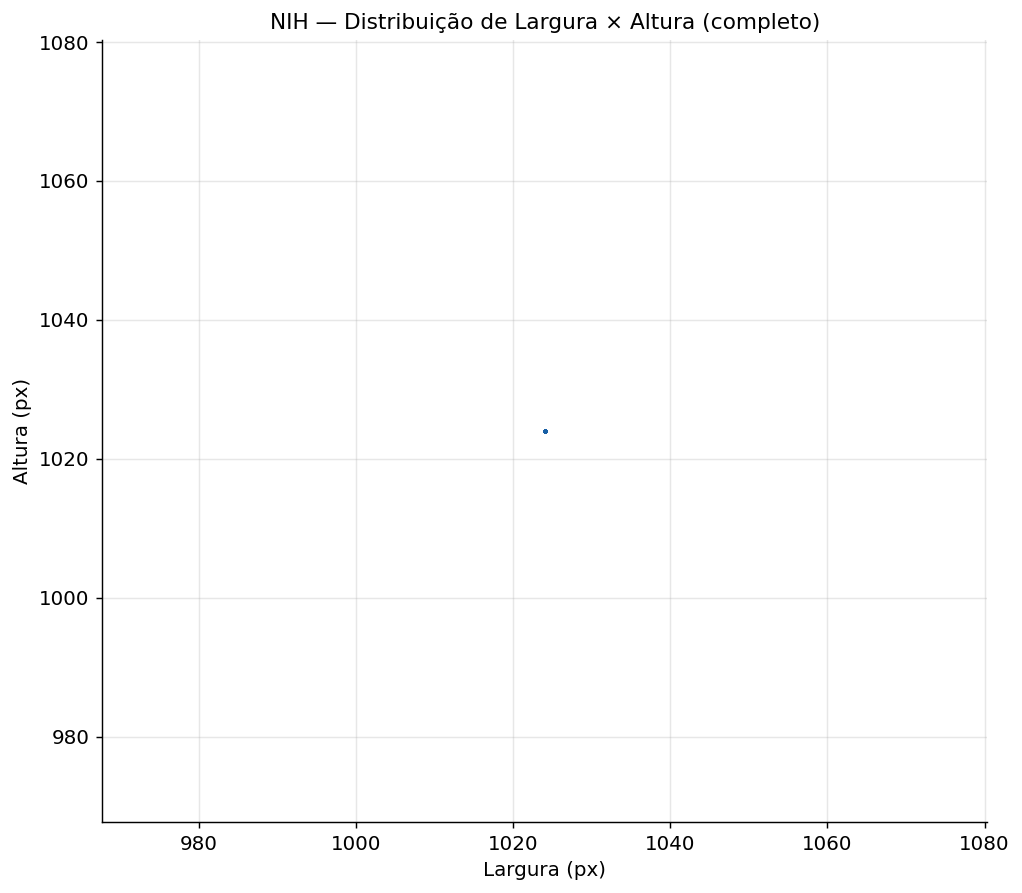

  Salvo: MyDrive/Results/analise_NIH/plots/sec01_image_sizes.png


In [ ]:
section('SEÇÃO 1 — Distribuição de Tamanhos de Imagem (NIH)')

def measure_image_sizes(paths, n=None, label=''):
    valid = [p for p in paths if p and os.path.exists(str(p))]
    if n is not None:
        valid = list(np.random.choice(valid, min(n, len(valid)), replace=False))
    sizes = []
    for p in tqdm(valid, desc=f'Medindo {label}', leave=False):
        try:
            with Image.open(p) as img:
                sizes.append(img.size)
        except Exception:
            pass
    return sizes

nih_paths = df_nih['abs_path'].dropna().tolist()
nih_sizes = measure_image_sizes(nih_paths, label='NIH completo')

ws = [s[0] for s in nih_sizes]; hs = [s[1] for s in nih_sizes]
log(f'NIH — Tamanhos ({len(nih_sizes):,} imagens medidas):')
log(f'  Largura  : min={min(ws)} | max={max(ws)} | mediana={int(np.median(ws))}')
log(f'  Altura   : min={min(hs)} | max={max(hs)} | mediana={int(np.median(hs))}')
log(f'  Tamanhos únicos: {len(set(nih_sizes))}')

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(ws, hs, alpha=0.3, s=2, color=C_NIH)
ax.set_title('NIH — Distribuição de Largura × Altura (completo)')
ax.set_xlabel('Largura (px)'); ax.set_ylabel('Altura (px)')
ax.grid(alpha=0.3)
save_fig(fig, f'{PLOTS_NIH}/sec01_image_sizes.png')


---
# SEÇÃO 2 — Distribuição por Label


SEÇÃO 2 — Distribuição por Label (NIH)
NIH — Positivos por label (112,120 imagens total):
  Infiltration                19,894  ( 17.74%)
  Effusion                    13,317  ( 11.88%)
  Atelectasis                 11,559  ( 10.31%)
  Nodule                       6,331  (  5.65%)
  Mass                         5,782  (  5.16%)
  Pneumothorax                 5,302  (  4.73%)
  Consolidation                4,667  (  4.16%)
  Pleural_Thickening           3,385  (  3.02%)
  Cardiomegaly                 2,776  (  2.48%)
  Emphysema                    2,516  (  2.24%)
  Edema                        2,303  (  2.05%)
  Fibrosis                     1,686  (  1.50%)
  Pneumonia                    1,431  (  1.28%)
  Hernia                         227  (  0.20%)


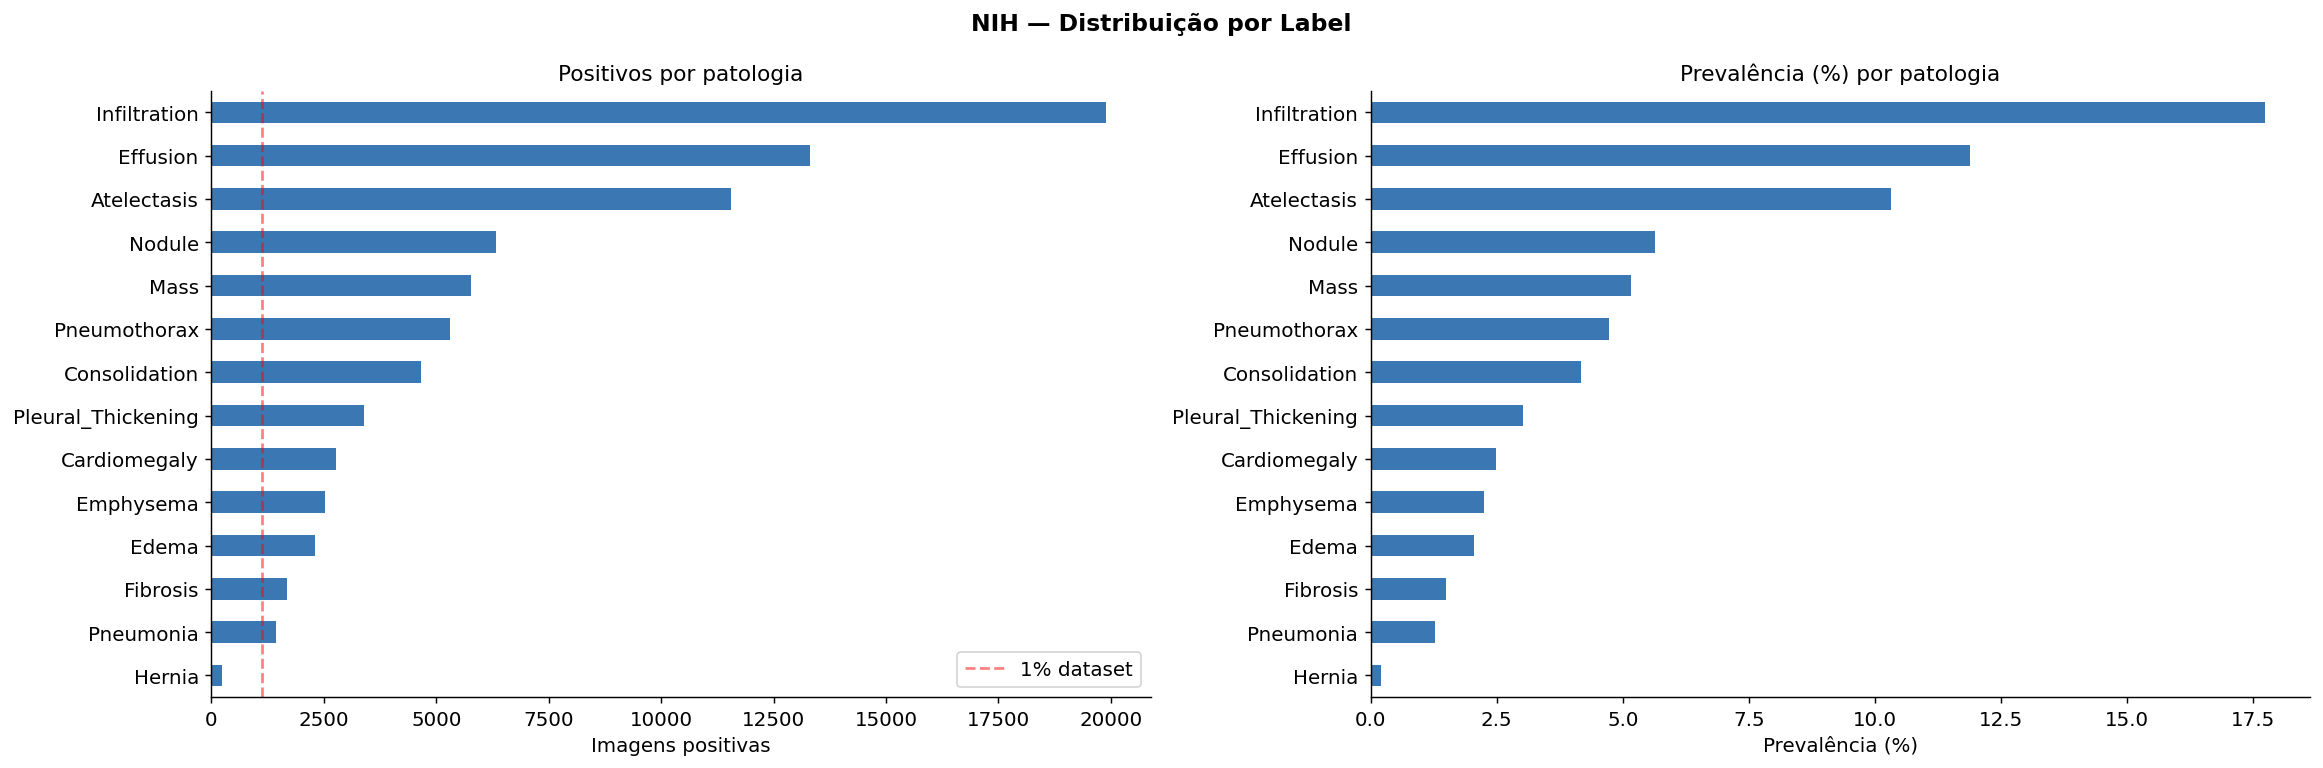

  Salvo: MyDrive/Results/analise_NIH/plots/sec02_label_distribution.png


In [ ]:
section('SEÇÃO 2 — Distribuição por Label (NIH)')

nih_counts = df_nih[NIH_LABELS].sum().sort_values(ascending=False)
nih_prev   = nih_counts / len(df_nih) * 100

log(f'NIH — Positivos por label ({len(df_nih):,} imagens total):')
for lbl in nih_counts.index:
    log(f'  {lbl:<25} {int(nih_counts[lbl]):>8,}  ({nih_prev[lbl]:>6.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('NIH — Distribuição por Label', fontsize=13, fontweight='bold')

nih_counts.sort_values().plot(kind='barh', ax=axes[0], color=C_NIH, alpha=0.85)
axes[0].set_title('Positivos por patologia')
axes[0].set_xlabel('Imagens positivas')
axes[0].axvline(len(df_nih)*0.01, color='red', linestyle='--', alpha=0.5, label='1% dataset')
axes[0].legend()

nih_prev.sort_values().plot(kind='barh', ax=axes[1], color=C_NIH, alpha=0.85)
axes[1].set_title('Prevalência (%) por patologia')
axes[1].set_xlabel('Prevalência (%)')

save_fig(fig, f'{PLOTS_NIH}/sec02_label_distribution.png')
nih_counts.to_frame('count').assign(prevalencia_pct=nih_prev).to_csv(f'{TABLES_DIR}/02_nih_counts.csv')


---
# SEÇÃO 4 — Desbalanceamento


SEÇÃO 4 — Desbalanceamento (NIH)
NIH — Imbalance ratio (negativos:positivos):
  Hernia                       492.9:1  (227 pos)
  Pneumonia                     77.4:1  (1,431 pos)
  Fibrosis                      65.5:1  (1,686 pos)
  Edema                         47.7:1  (2,303 pos)
  Emphysema                     43.6:1  (2,516 pos)
  Cardiomegaly                  39.4:1  (2,776 pos)
  Pleural_Thickening            32.1:1  (3,385 pos)
  Consolidation                 23.0:1  (4,667 pos)
  Pneumothorax                  20.1:1  (5,302 pos)
  Mass                          18.4:1  (5,782 pos)
  Nodule                        16.7:1  (6,331 pos)
  Atelectasis                    8.7:1  (11,559 pos)
  Effusion                       7.4:1  (13,317 pos)
  Infiltration                   4.6:1  (19,894 pos)

Label mais frequente : Infiltration (19,894)
Label menos frequente: Hernia (227)
Razão max/min        : 87.6×


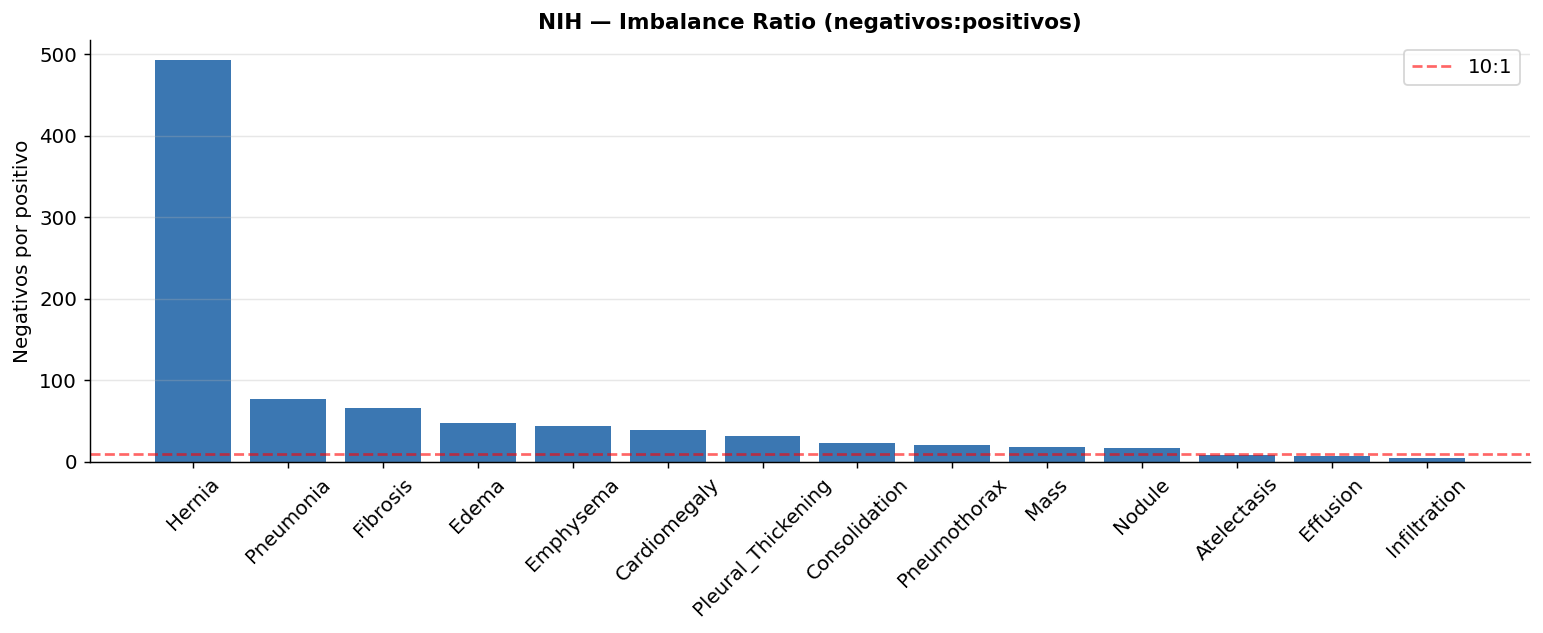

  Salvo: MyDrive/Results/analise_NIH/plots/sec04_imbalance_ratio.png


In [ ]:
section('SEÇÃO 4 — Desbalanceamento (NIH)')

nih_pos   = df_nih[NIH_LABELS].sum()
nih_neg   = len(df_nih) - nih_pos
nih_ratio = (nih_neg / nih_pos).replace([np.inf, -np.inf], np.nan)

log('NIH — Imbalance ratio (negativos:positivos):')
for lbl in nih_ratio.sort_values(ascending=False).index:
    log(f'  {lbl:<25} {nih_ratio[lbl]:>8.1f}:1  ({int(nih_pos[lbl]):,} pos)')

max_lbl = nih_counts.idxmax(); min_lbl = nih_counts.idxmin()
log(f'\nLabel mais frequente : {max_lbl} ({int(nih_counts[max_lbl]):,})')
log(f'Label menos frequente: {min_lbl} ({int(nih_counts[min_lbl]):,})')
log(f'Razão max/min        : {nih_counts[max_lbl]/nih_counts[min_lbl]:.1f}×')

nih_ratio_clean = nih_ratio.dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(nih_ratio_clean.index, nih_ratio_clean.values, color=C_NIH, alpha=0.85)
ax.set_title('NIH — Imbalance Ratio (negativos:positivos)', fontweight='bold')
ax.set_ylabel('Negativos por positivo')
ax.tick_params(axis='x', rotation=45)
ax.axhline(10, color='red', linestyle='--', alpha=0.6, label='10:1')
ax.legend(); ax.grid(axis='y', alpha=0.3)
save_fig(fig, f'{PLOTS_NIH}/sec04_imbalance_ratio.png')

pd.DataFrame({'imbalance_ratio': nih_ratio_clean}).to_csv(f'{TABLES_DIR}/04_nih_imbalance.csv')


---
# SEÇÃO 7 — Complexidade Multi-Label


SEÇÃO 7 — Complexidade Multi-Label (NIH)
NIH — Labels por imagem:
  0 labels: 60,361 imagens (53.8%)
  1 labels: 30,963 imagens (27.6%)
  2 labels: 14,306 imagens (12.8%)
  3 labels: 4,856 imagens (4.3%)
  4 labels: 1,247 imagens (1.1%)
  5 labels: 301 imagens (0.3%)
  6 labels: 67 imagens (0.1%)
  7 labels: 16 imagens (0.0%)
  8 labels: 1 imagens (0.0%)
  9 labels: 2 imagens (0.0%)
  Média: 0.72 | Mediana: 0.0 | Max: 9


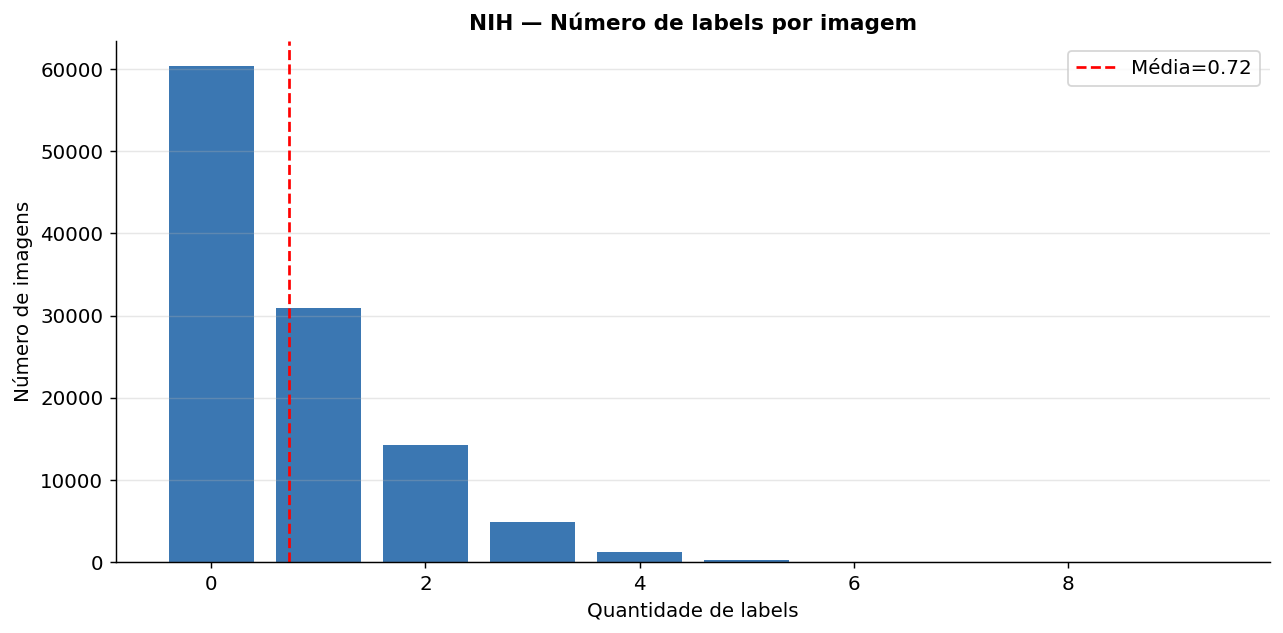

  Salvo: MyDrive/Results/analise_NIH/plots/sec07_multilabel_complexity.png


In [ ]:
section('SEÇÃO 7 — Complexidade Multi-Label (NIH)')

nih_n_labels   = df_nih[NIH_LABELS].sum(axis=1)
nih_label_dist = nih_n_labels.value_counts().sort_index()

log('NIH — Labels por imagem:')
for n, cnt in nih_label_dist.items():
    log(f'  {n} labels: {cnt:,} imagens ({cnt/len(df_nih)*100:.1f}%)')
log(f'  Média: {nih_n_labels.mean():.2f} | Mediana: {nih_n_labels.median():.1f} | Max: {int(nih_n_labels.max())}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(nih_label_dist.index, nih_label_dist.values, color=C_NIH, alpha=0.85)
ax.set_title('NIH — Número de labels por imagem', fontweight='bold')
ax.set_xlabel('Quantidade de labels'); ax.set_ylabel('Número de imagens')
ax.axvline(nih_n_labels.mean(), color='red', linestyle='--', label=f'Média={nih_n_labels.mean():.2f}')
ax.legend(); ax.grid(axis='y', alpha=0.3)
save_fig(fig, f'{PLOTS_NIH}/sec07_multilabel_complexity.png')


---
# SEÇÃO 8 — Combinações de Labels Mais Frequentes


SEÇÃO 8 — Combinações de Labels Mais Frequentes (NIH)
NIH — Top 20 combinações de labels:
   1. Effusion + Infiltration                                       1,604
   2. Atelectasis + Infiltration                                    1,350
   3. Atelectasis + Effusion                                        1,167
   4. Infiltration + Nodule                                           829
   5. Atelectasis + Effusion + Infiltration                           739
   6. Cardiomegaly + Effusion                                         484
   7. Consolidation + Infiltration                                    441
   8. Infiltration + Mass                                             420
   9. Effusion + Pneumothorax                                         403
  10. Effusion + Mass                                                 402
  11. Atelectasis + Consolidation                                     398
  12. Mass + Nodule                                                   396
  13. Edema + Infiltr

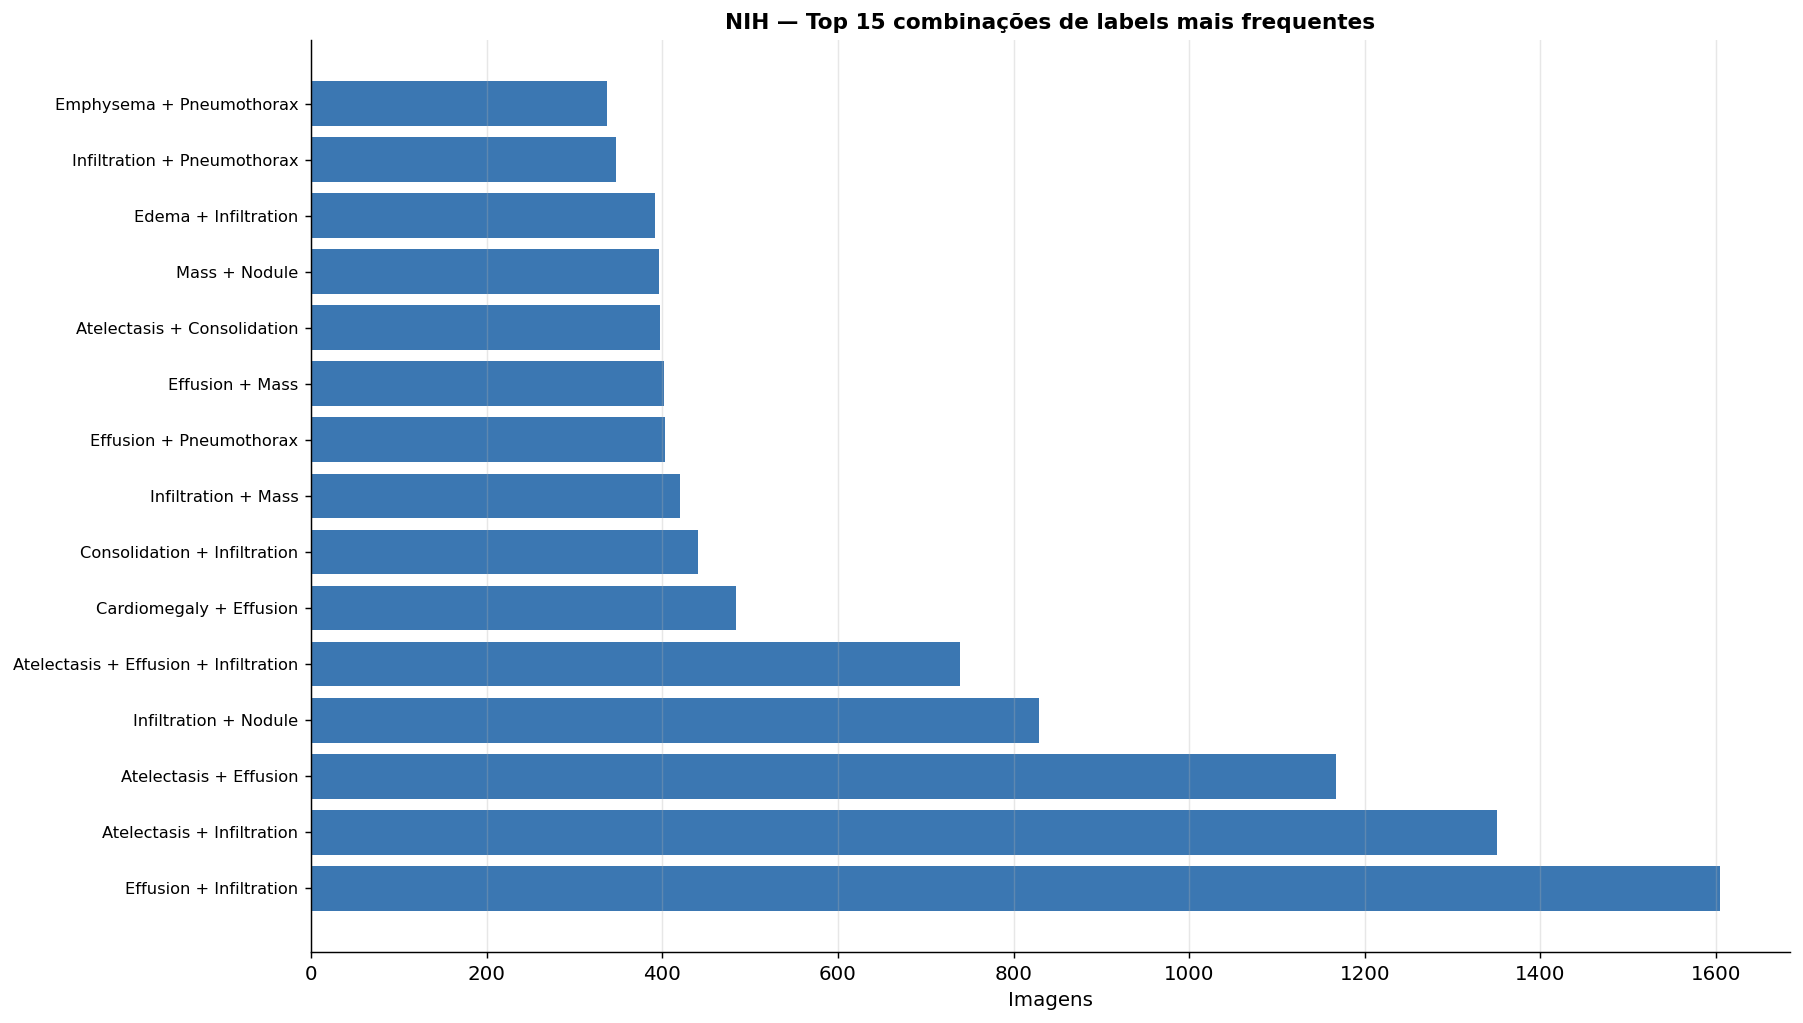

  Salvo: MyDrive/Results/analise_NIH/plots/sec08_label_combinations.png


In [ ]:
section('SEÇÃO 8 — Combinações de Labels Mais Frequentes (NIH)')

def top_combinations(df, labels, n_top=20):
    combos = Counter()
    for _, row in df[labels].iterrows():
        active = tuple(sorted([l for l in labels if row[l] == 1]))
        if len(active) > 1:
            combos[active] += 1
    return combos.most_common(n_top)

nih_combos = top_combinations(df_nih, NIH_LABELS)
log('NIH — Top 20 combinações de labels:')
for i, (combo, cnt) in enumerate(nih_combos, 1):
    log(f'  {i:>2}. {" + ".join(combo):<60} {cnt:>6,}')

fig, ax = plt.subplots(figsize=(14, 8))
labels_str = [' + '.join(c) for c, _ in nih_combos[:15]]
counts     = [v for _, v in nih_combos[:15]]
ax.barh(range(len(labels_str)), counts, color=C_NIH, alpha=0.85)
ax.set_yticks(range(len(labels_str))); ax.set_yticklabels(labels_str, fontsize=9)
ax.set_title('NIH — Top 15 combinações de labels mais frequentes', fontweight='bold')
ax.set_xlabel('Imagens'); ax.grid(axis='x', alpha=0.3)
save_fig(fig, f'{PLOTS_NIH}/sec08_label_combinations.png')

pd.DataFrame([('+'.join(c), v) for c,v in nih_combos], columns=['combo','count']).to_csv(
    f'{TABLES_DIR}/08_nih_combos.csv', index=False)


---
# SEÇÃO 9 — No Finding vs Com Patologia


SEÇÃO 9 — No Finding vs Com Patologia (NIH)
NIH:
  No Finding    : 60,361 (53.8%)
  Com patologia : 51,759 (46.2%)

NIH — Imagens com múltiplas patologias:
  1 label   : 30,963 (27.6%)
  2+ labels : 20,796 (18.5%)


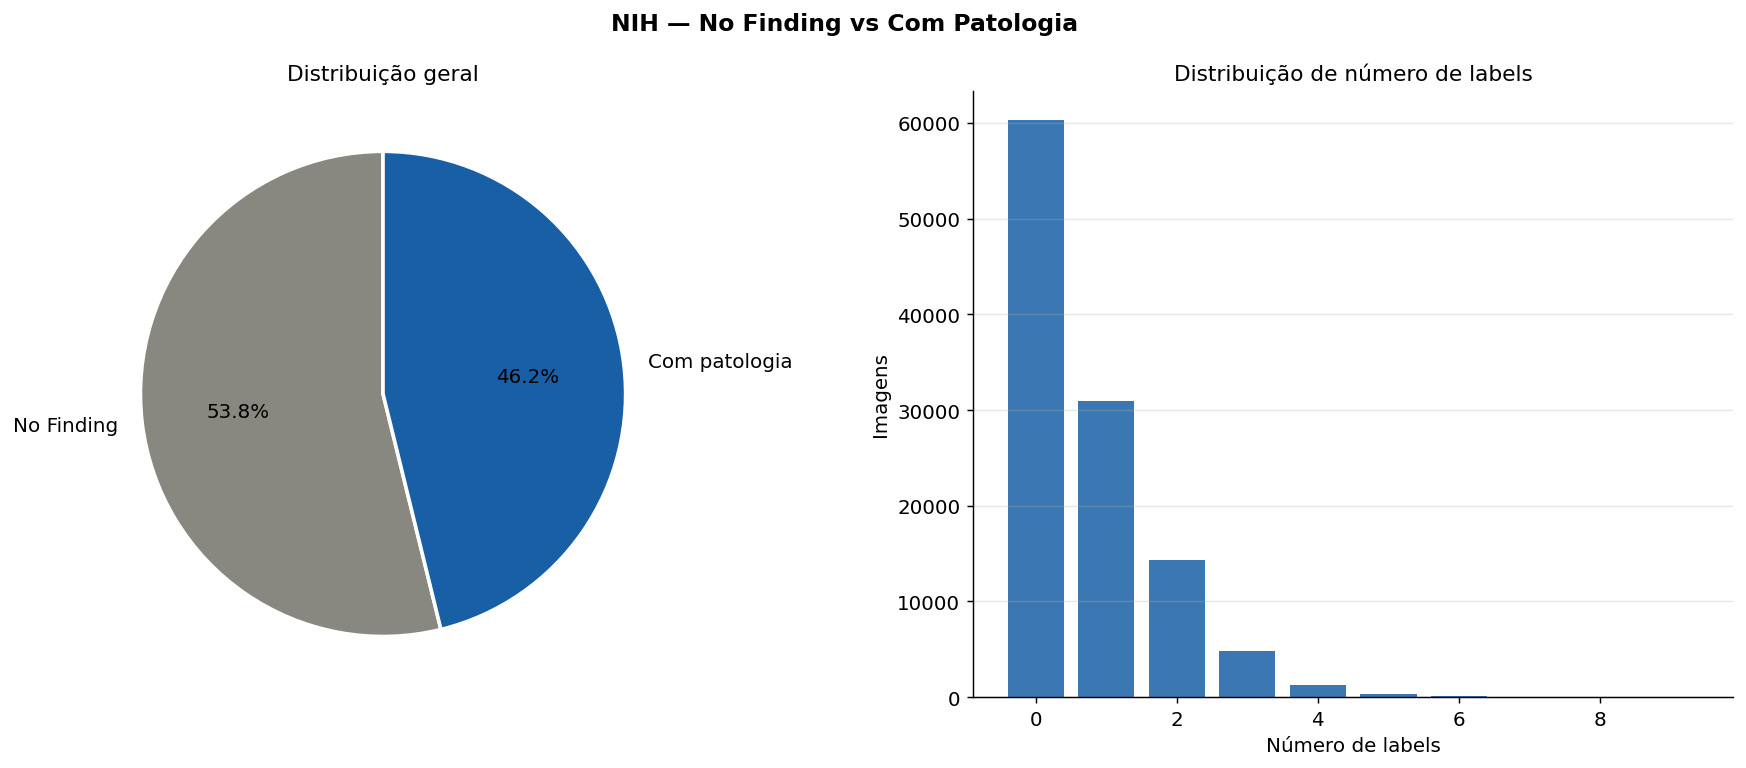

  Salvo: MyDrive/Results/analise_NIH/plots/sec09_no_finding.png


In [ ]:
section('SEÇÃO 9 — No Finding vs Com Patologia (NIH)')

nih_nf  = (df_nih['Finding Labels'] == 'No Finding').sum()
nih_has = len(df_nih) - nih_nf

log('NIH:')
log(f'  No Finding    : {nih_nf:,} ({nih_nf/len(df_nih)*100:.1f}%)')
log(f'  Com patologia : {nih_has:,} ({nih_has/len(df_nih)*100:.1f}%)')

nih_n_labels = df_nih[NIH_LABELS].sum(axis=1)
log(f'\nNIH — Imagens com múltiplas patologias:')
log(f'  1 label   : {(nih_n_labels==1).sum():,} ({(nih_n_labels==1).mean()*100:.1f}%)')
log(f'  2+ labels : {(nih_n_labels>=2).sum():,} ({(nih_n_labels>=2).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('NIH — No Finding vs Com Patologia', fontsize=13, fontweight='bold')

axes[0].pie([nih_nf, nih_has], labels=['No Finding','Com patologia'],
            autopct='%1.1f%%', colors=[C_GRAY, C_NIH],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribuição geral')

nih_complexity = nih_n_labels.value_counts().sort_index().head(10)
axes[1].bar(nih_complexity.index, nih_complexity.values, color=C_NIH, alpha=0.85)
axes[1].set_title('Distribuição de número de labels')
axes[1].set_xlabel('Número de labels'); axes[1].set_ylabel('Imagens')
axes[1].grid(axis='y', alpha=0.3)

save_fig(fig, f'{PLOTS_NIH}/sec09_no_finding.png')


---
# SEÇÃO 11 — Demografias: Idade por Patologia


SEÇÃO 11 — Distribuição de Idade por Patologia (NIH)
NIH — Idade: min=1 | max=414 | média=46.9 | mediana=49.0

Label                        Média positivos    Média negativos
-----------------------------------------------------------------
Atelectasis                            50.5              46.5
Cardiomegaly                           47.3              46.9
Effusion                               49.8              46.5
Infiltration                           46.2              47.1
Mass                                   48.8              46.8
Nodule                                 49.5              46.7
Pneumonia                              44.9              46.9
Pneumothorax                           46.5              46.9
Consolidation                          46.7              46.9
Edema                                  45.6              46.9
Emphysema                              50.3              46.8
Fibrosis                               52.7              46.8
Pleural_Thicke

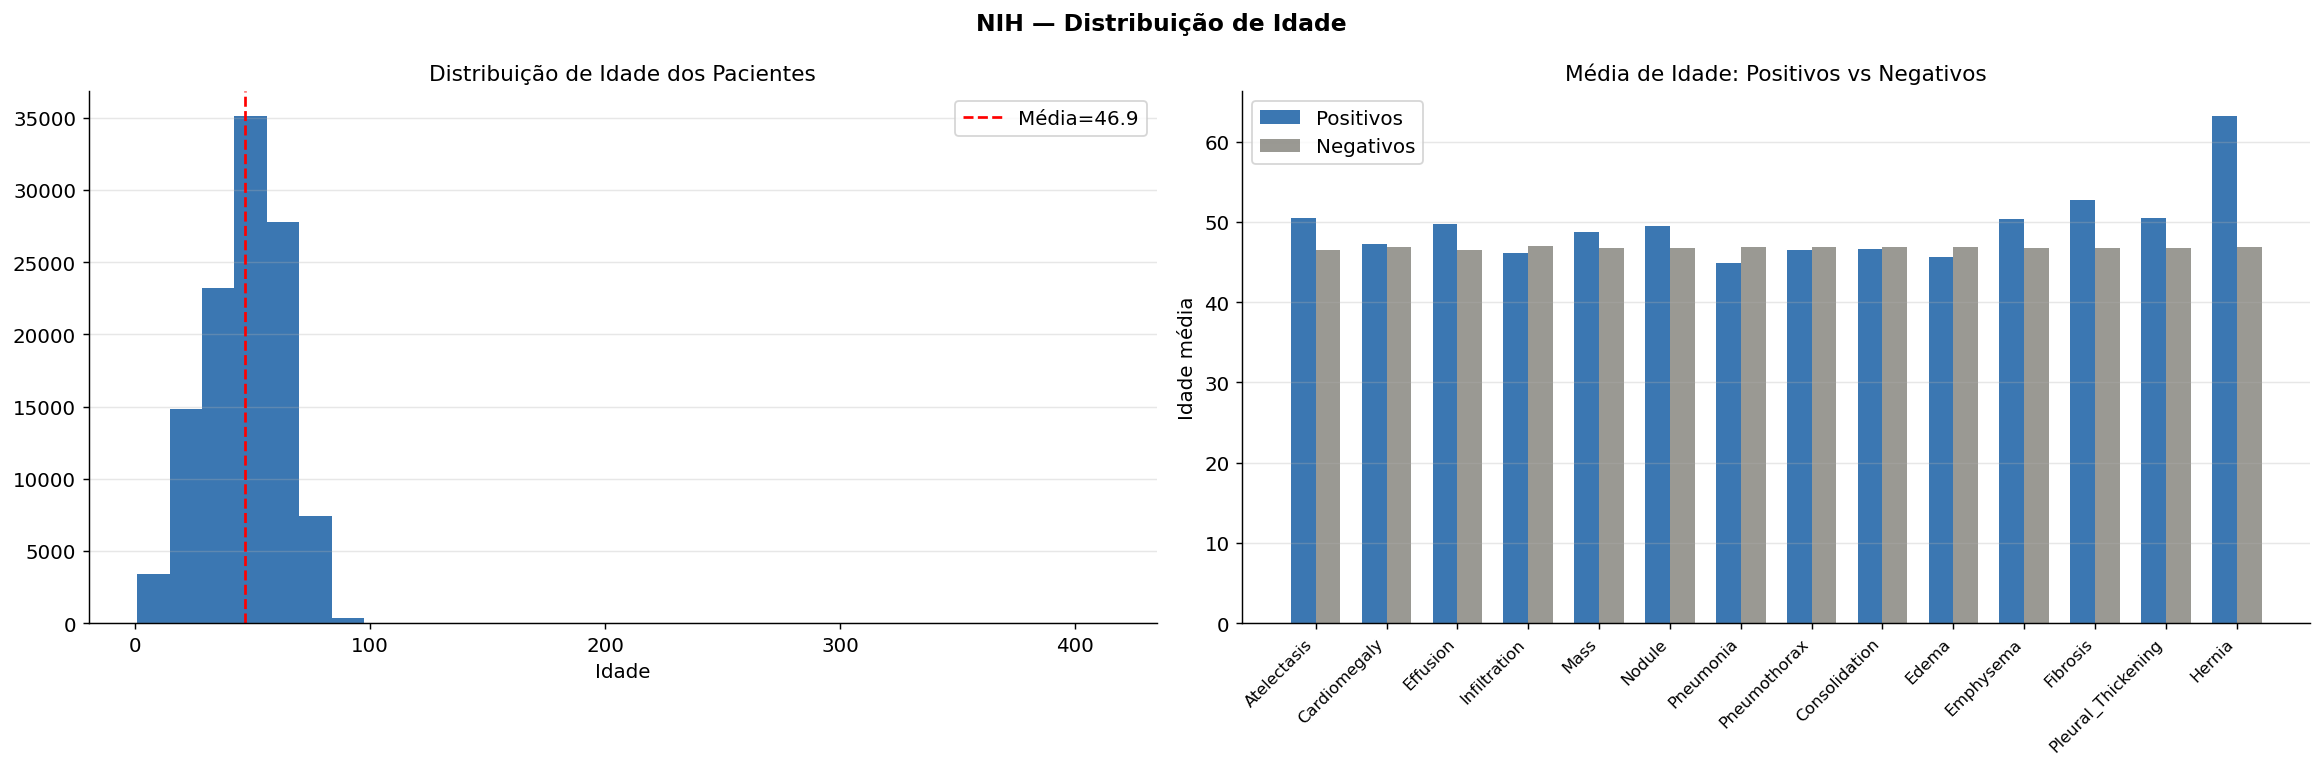

  Salvo: MyDrive/Results/analise_NIH/plots/sec11_age_distribution.png


In [ ]:
section('SEÇÃO 11 — Distribuição de Idade por Patologia (NIH)')

age_col_nih = 'Patient Age' if 'Patient Age' in df_nih.columns else None

if not age_col_nih:
    log('Coluna de idade não encontrada no NIH.')
else:
    nih_age = df_nih[age_col_nih].dropna()
    log(f'NIH — Idade: min={nih_age.min():.0f} | max={nih_age.max():.0f} | média={nih_age.mean():.1f} | mediana={nih_age.median():.1f}')

    age_by_label = {}
    log(f'\n{"Label":<25} {"Média positivos":>18} {"Média negativos":>18}')
    log('-' * 65)
    for lbl in NIH_LABELS:
        pos_age = df_nih[df_nih[lbl]==1][age_col_nih].dropna()
        neg_age = df_nih[df_nih[lbl]==0][age_col_nih].dropna()
        pm = pos_age.mean() if len(pos_age)>0 else None
        nm = neg_age.mean() if len(neg_age)>0 else None
        age_by_label[lbl] = {'pos_mean': pm, 'neg_mean': nm}
        if pm and nm:
            log(f'{lbl:<25} {pm:>17.1f} {nm:>17.1f}')

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('NIH — Distribuição de Idade', fontsize=13, fontweight='bold')

    axes[0].hist(nih_age, bins=30, color=C_NIH, alpha=0.85)
    axes[0].axvline(nih_age.mean(), color='red', linestyle='--', label=f'Média={nih_age.mean():.1f}')
    axes[0].set_title('Distribuição de Idade dos Pacientes')
    axes[0].set_xlabel('Idade'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

    valid_lbl = {l: v for l, v in age_by_label.items() if v['pos_mean'] and v['neg_mean']}
    if valid_lbl:
        lbls_a = list(valid_lbl.keys()); x = np.arange(len(lbls_a)); w = 0.35
        axes[1].bar(x-w/2, [valid_lbl[l]['pos_mean'] for l in lbls_a], w,
                    label='Positivos', color=C_NIH, alpha=0.85)
        axes[1].bar(x+w/2, [valid_lbl[l]['neg_mean'] for l in lbls_a], w,
                    label='Negativos', color=C_GRAY, alpha=0.85)
        axes[1].set_xticks(x); axes[1].set_xticklabels(lbls_a, rotation=45, ha='right', fontsize=9)
        axes[1].set_title('Média de Idade: Positivos vs Negativos')
        axes[1].set_ylabel('Idade média'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

    save_fig(fig, f'{PLOTS_NIH}/sec11_age_distribution.png')
    pd.DataFrame(age_by_label).T.to_csv(f'{TABLES_DIR}/11_nih_age_by_label.csv')


---
# SEÇÃO 13 — Arquivos Faltantes vs CSV

In [ ]:
section('SEÇÃO 13 — Arquivos Faltantes vs CSV (NIH)')

log('Verificando NIH — todos os arquivos...')
t0 = time.time()
nih_paths_all = df_nih['abs_path'].dropna()
nih_exists    = nih_paths_all.apply(os.path.exists)
nih_missing   = (~nih_exists).sum()
nih_found     = nih_exists.sum()
log(f'\nNIH — verificação completa ({len(nih_paths_all):,} imagens, {time.time()-t0:.0f}s):')
log(f'  Encontrados : {nih_found:,}')
log(f'  Faltando    : {nih_missing:,}')
log(f'  Cobertura   : {nih_found/len(nih_paths_all)*100:.3f}%')

if nih_missing > 0:
    missing_list = nih_paths_all[~nih_exists].tolist()
    log(f'  Primeiros faltantes:')
    for p in missing_list[:10]:
        log(f'    {os.path.basename(p)}')

import json as _json
missing_report = {
    'NIH': {'total': int(len(nih_paths_all)), 'found': int(nih_found), 'missing': int(nih_missing)}
}
with open(f'{TABLES_DIR}/sec13_nih_missing.json', 'w') as f:
    _json.dump(missing_report, f, indent=2)
log(f'\n Relatório salvo.')



SEÇÃO 13 — Arquivos Faltantes vs CSV (NIH)
Verificando NIH — todos os arquivos...

NIH — verificação completa (112,120 imagens, 26s):
  Encontrados : 112,120
  Faltando    : 0
  Cobertura   : 100.000%

 Relatório salvo.


---
# SEÇÃO 14 — Distribuição de Estudos por Paciente


SEÇÃO 14 — Distribuição de Estudos por Paciente (NIH)
NIH — Estudos por paciente:
  Pacientes únicos    : 30,805
  Média estudos/pac.  : 3.64
  Mediana             : 1.0
  Máx estudos/pac.    : 184
  1 estudo (único)    : 17,503 (56.8%)
  2-4 estudos         : 7,543
  5+ estudos          : 5,759 (18.7%)


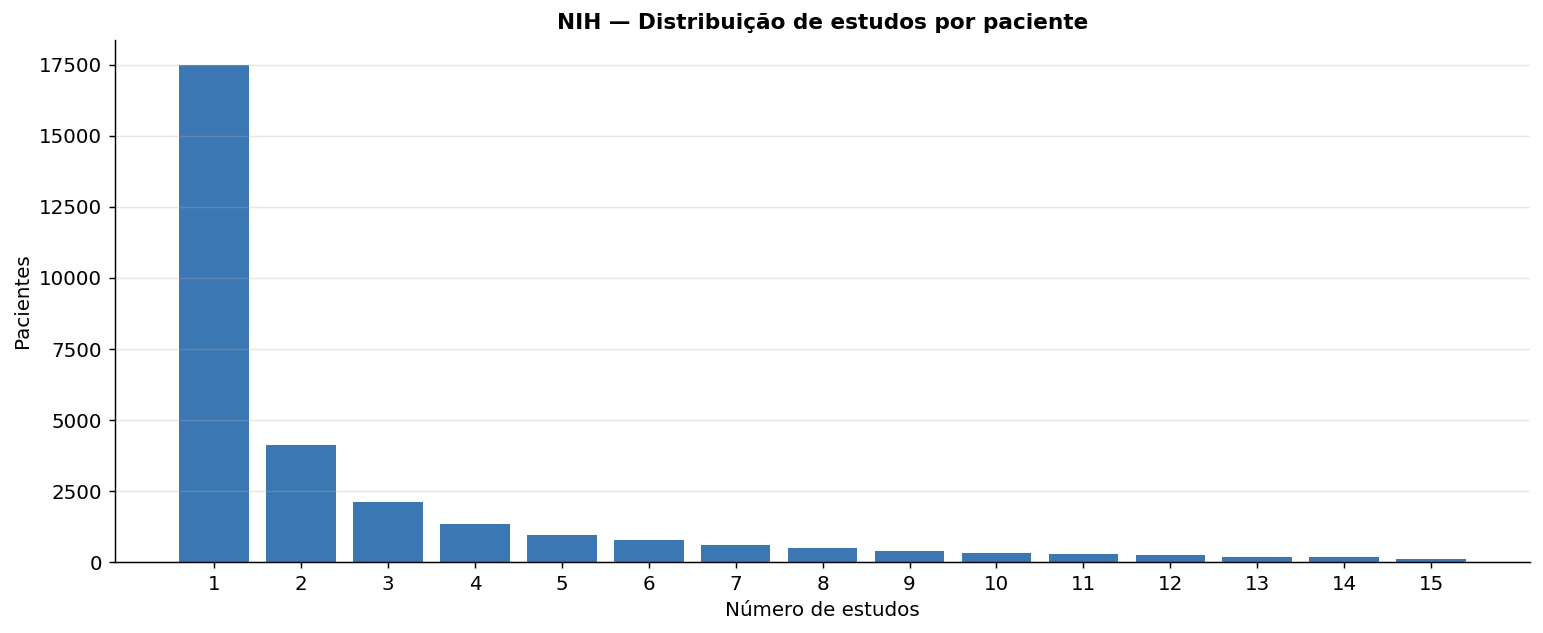

  Salvo: MyDrive/Results/analise_NIH/plots/sec14_studies_per_patient.png


In [ ]:
section('SEÇÃO 14 — Distribuição de Estudos por Paciente (NIH)')

if 'Patient ID' not in df_nih.columns:
    log('Coluna Patient ID não encontrada.')
else:
    nih_studies = df_nih.groupby('Patient ID').size()
    log('NIH — Estudos por paciente:')
    log(f'  Pacientes únicos    : {len(nih_studies):,}')
    log(f'  Média estudos/pac.  : {nih_studies.mean():.2f}')
    log(f'  Mediana             : {nih_studies.median():.1f}')
    log(f'  Máx estudos/pac.    : {nih_studies.max()}')
    log(f'  1 estudo (único)    : {(nih_studies==1).sum():,} ({(nih_studies==1).mean()*100:.1f}%)')
    log(f'  2-4 estudos         : {((nih_studies>=2)&(nih_studies<=4)).sum():,}')
    log(f'  5+ estudos          : {(nih_studies>=5).sum():,} ({(nih_studies>=5).mean()*100:.1f}%)')

    nih_study_dist = nih_studies.value_counts().sort_index().head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(nih_study_dist.index.astype(str), nih_study_dist.values, color=C_NIH, alpha=0.85)
    ax.set_title('NIH — Distribuição de estudos por paciente', fontweight='bold')
    ax.set_xlabel('Número de estudos'); ax.set_ylabel('Pacientes')
    ax.grid(axis='y', alpha=0.3)
    save_fig(fig, f'{PLOTS_NIH}/sec14_studies_per_patient.png')
    nih_studies.value_counts().sort_index().to_csv(f'{TABLES_DIR}/14_nih_studies_per_patient.csv')


---
# SEÇÃO 16 — Relatório Completo e Resumo Estratégico

In [ ]:
section('SEÇÃO 16 — Relatório Completo NIH')

summary_lines = [
    '',
    '=' * 65,
    'RESUMO ESTRATÉGICO — NIH ChestX-ray14',
    '=' * 65,
    '',
    '[1] DATASET',
    f'    Total de imagens  : {len(df_nih):,}',
    f'    Arquivos indexados: {len(nih_img_files):,}',
    f'    Resolução         : PNG 1024×1024 (uniforme)',
    '',
    '[2] DESBALANCEAMENTO',
    f'    Label mais freq.  : {nih_counts.idxmax()} ({int(nih_counts.max()):,} imgs)',
    f'    Label menos freq. : {nih_counts.idxmin()} ({int(nih_counts.min()):,} imgs)',
    f'    Razão max/min     : {nih_counts.max()/nih_counts.min():.0f}×',
    '    → Usar Weighted Loss ou Focal Loss no treino M1.',
    '',
    '[3] COMPLEXIDADE MULTI-LABEL',
    f'    Média de labels/imagem: {df_nih[NIH_LABELS].sum(axis=1).mean():.2f}',
    '    → Alta co-ocorrência entre alguns pares — considerar modelar dependências.',
    '',
    '[4] SPLIT',
    f'    Train : {(df_nih.split=="train").sum():,} imagens',
    f'    Test  : {(df_nih.split=="test").sum():,} imagens',
    '    → Split oficial já separa pacientes entre train e test.',
    '',
    '=' * 65,
]

for l in summary_lines:
    log(l)

with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(REPORT_LINES))

print(f'\nRelatório salvo: {REPORT_PATH}')
print(f'  {len(REPORT_LINES)} linhas')
print(f'\nArquivos gerados em {ANALYSIS_DIR.replace(BASE_DRIVE, "MyDrive")}:')
for root, dirs, files in os.walk(ANALYSIS_DIR):
    for fn in sorted(files):
        fpath = os.path.join(root, fn)
        size  = os.path.getsize(fpath)
        unit  = 'KB' if size < 1024**2 else 'MB'
        sv    = size/1024 if size < 1024**2 else size/1024**2
        rel   = fpath.replace(ANALYSIS_DIR+'/', '')
        print(f'  {rel:<55} {sv:>6.1f} {unit}')



SEÇÃO 16 — Relatório Completo NIH

RESUMO ESTRATÉGICO — NIH ChestX-ray14

[1] DATASET
    Total de imagens  : 112,120
    Arquivos indexados: 112,120
    Resolução         : PNG 1024×1024 (uniforme)

[2] DESBALANCEAMENTO
    Label mais freq.  : Infiltration (19,894 imgs)
    Label menos freq. : Hernia (227 imgs)
    Razão max/min     : 88×
    → Usar Weighted Loss ou Focal Loss no treino M1.

[3] COMPLEXIDADE MULTI-LABEL
    Média de labels/imagem: 0.72
    → Alta co-ocorrência entre alguns pares — considerar modelar dependências.

[4] SPLIT
    Train : 86,524 imagens
    Test  : 25,596 imagens
    → Split oficial já separa pacientes entre train e test.


Relatório salvo: /content/drive/MyDrive/Results/analise_NIH/relatorio_NIH.txt
  173 linhas

Arquivos gerados em MyDrive/Results/analise_NIH:
  relatorio_NIH.txt                                          7.8 KB
  plots/sec01_image_sizes.png                               37.0 KB
  plots/sec02_label_distribution.png                      